# Regression & econometrics

Linear regression is the workhorse of empirical finance: it estimates **betas**
(factor exposures), builds **hedge ratios**, and underlies the time-series models
later in this collection. This notebook covers the mechanics *and* the traps.

The model is $\;y = X\beta + \varepsilon$, and Ordinary Least Squares (OLS)
minimises the squared residuals, with the closed-form solution

$$ \hat\beta = (X^\top X)^{-1} X^\top y. $$

But a fitted line is worthless without **inference** (are the coefficients real?)
and **diagnostics** (are the assumptions met?). The most dangerous trap in
finance — **spurious regression** between non-stationary series — is the reason
the cointegration machinery (notebook 20) exists.

**Roadmap**

1. OLS by hand — coefficients, standard errors, t-stats, $R^2$
2. A real regression — the **CAPM beta** of a stock
3. Multiple regression and **multicollinearity**
4. The **spurious-regression** trap — and how to detect it
5. Residual diagnostics


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from qufin.timeseries import engle_granger, ljung_box, jarque_bera

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def ols(X, y):
    """OLS with classical inference. X has no intercept column; one is added."""
    X = np.column_stack([np.ones(len(y)), np.asarray(X, dtype=float).reshape(len(y), -1)])
    n, k = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    sigma2 = float(resid @ resid) / (n - k)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    tstat = beta / se
    pval = 2 * stats.t.sf(np.abs(tstat), df=n - k)
    ss_res = float(resid @ resid)
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)
    return {'beta': beta, 'se': se, 't': tstat, 'p': pval, 'r2': r2,
            'adj_r2': adj_r2, 'resid': resid}


## 1. OLS by hand

We fit a line to noisy data generated from a *known* relationship
$y = 2 + 0.5x + \varepsilon$, recover the coefficients, and read off their
**standard errors** (estimation uncertainty) and **t-statistics** (coefficient
divided by its standard error — large magnitude ⇒ the effect is real). The
$R^2$ reports the fraction of variance the line explains.


term        estimate   std err   t-stat   p-value
intercept      2.009     0.057    35.45 6.61e-109
slope          0.482     0.031    15.32  1.72e-39

R^2 = 0.441   (true intercept 2.0, slope 0.5)


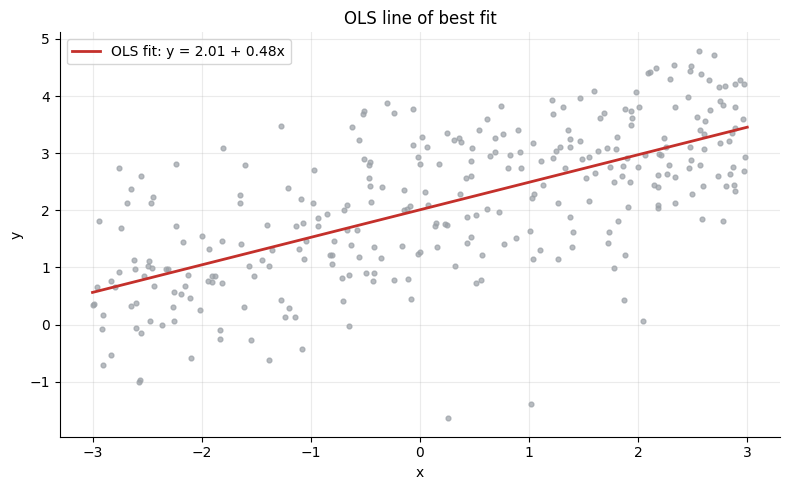

In [2]:
rng = np.random.default_rng(0)
n = 300
x = rng.uniform(-3, 3, n)
y = 2.0 + 0.5 * x + rng.normal(0, 1.0, n)        # true intercept 2, slope 0.5
res = ols(x, y)
print(f'{"term":<10}{"estimate":>10}{"std err":>10}{"t-stat":>9}{"p-value":>10}')
for name, b, s, t, p in zip(['intercept', 'slope'], res['beta'], res['se'], res['t'], res['p']):
    print(f'{name:<10}{b:>10.3f}{s:>10.3f}{t:>9.2f}{p:>10.2e}')
print(f'\nR^2 = {res["r2"]:.3f}   (true intercept 2.0, slope 0.5)')

xs = np.linspace(-3, 3, 50)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=12, color='#9aa0a6', alpha=0.7)
ax.plot(xs, res['beta'][0] + res['beta'][1] * xs, color='#c4302b', lw=2,
        label=f'OLS fit: y = {res["beta"][0]:.2f} + {res["beta"][1]:.2f}x')
ax.set_title('OLS line of best fit'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()


## 2. A real regression — the CAPM beta

Regressing a stock's **excess returns** on the **market's** excess returns gives
its **beta** — how much it amplifies market moves — and **alpha** (the
intercept), the return unexplained by the market. $R^2$ measures how much of the
stock's variance is market-driven (systematic) vs idiosyncratic.


beta  = 1.205  (t=56.6)   -> moves ~1.2x the market
alpha = +9.44%/yr (t=1.58)  -> not distinguishable from 0
R^2   = 0.56  -> 56% of variance is market-driven


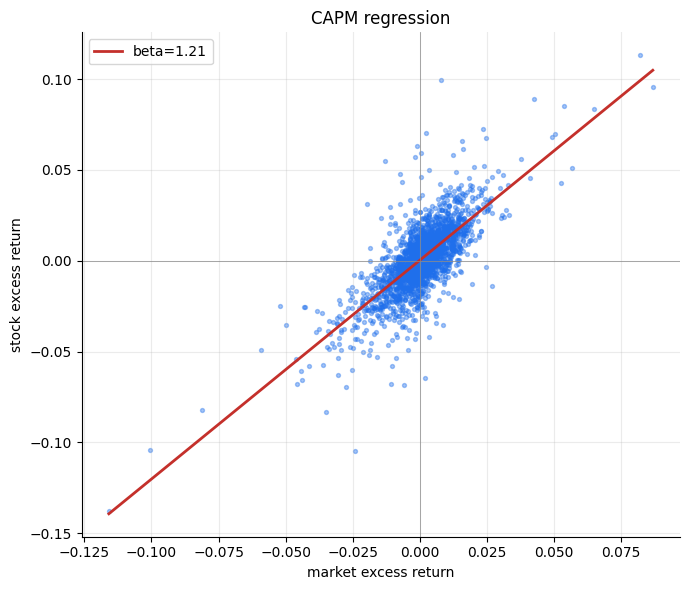

In [3]:
def load_pair(stock='AAPL', market='SPY', start='2015-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        raw = yf.download([stock, market], start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][[stock, market]].dropna()
        if len(close) > 500:
            r = close.to_numpy('float64')
            return np.diff(np.log(r[:, 0])), np.diff(np.log(r[:, 1]))
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic (true beta 1.3)')
    rng = np.random.default_rng(1); n = 2000
    mkt = rng.normal(0.0003, 0.01, n)
    stk = 0.0001 + 1.3 * mkt + rng.normal(0, 0.012, n)
    return stk, mkt

stock_ret, mkt_ret = load_pair()
rf = 0.04 / 252
capm = ols(mkt_ret - rf, stock_ret - rf)
alpha, beta = capm['beta']
print(f'beta  = {beta:.3f}  (t={capm["t"][1]:.1f})   -> moves ~{beta:.1f}x the market')
print(f'alpha = {alpha*252:+.2%}/yr (t={capm["t"][0]:.2f})  -> '
      f'{"significant" if capm["p"][0] < 0.05 else "not distinguishable from 0"}')
print(f'R^2   = {capm["r2"]:.2f}  -> {capm["r2"]:.0%} of variance is market-driven')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(mkt_ret, stock_ret, s=8, color='#1f6feb', alpha=0.4)
xs = np.linspace(mkt_ret.min(), mkt_ret.max(), 50)
ax.plot(xs, alpha + beta * xs, color='#c4302b', lw=2, label=f'beta={beta:.2f}')
ax.axhline(0, color='#888', lw=0.5); ax.axvline(0, color='#888', lw=0.5)
ax.set_xlabel('market excess return'); ax.set_ylabel('stock excess return')
ax.set_title('CAPM regression'); ax.legend()
plt.tight_layout(); plt.show()


## 3. Multiple regression & multicollinearity

With several regressors, OLS estimates each effect *holding the others fixed*.
But when two regressors are **highly correlated** (multicollinearity), the design
matrix $X^\top X$ becomes near-singular: coefficients turn unstable and their
**standard errors balloon**, even though the fit ($R^2$) stays high. The
condition number of $X^\top X$ is the warning light.


In [4]:
n = 500
x1 = rng.normal(0, 1, n)
x2 = x1 + rng.normal(0, 0.05, n)       # x2 almost identical to x1 -> collinear
x_indep = rng.normal(0, 1, n)
y2 = 1.0 + 2.0 * x1 - 1.0 * x_indep + rng.normal(0, 0.5, n)   # x2 truly irrelevant

well = ols(np.column_stack([x1, x_indep]), y2)
ill = ols(np.column_stack([x1, x2, x_indep]), y2)
print('Well-conditioned (x1, x_indep):')
print(f'  slopes={np.round(well["beta"][1:], 2)}  std errs={np.round(well["se"][1:], 3)}')
print('Add a near-duplicate x2 (collinear with x1):')
print(f'  slopes={np.round(ill["beta"][1:], 2)}  std errs={np.round(ill["se"][1:], 3)}'
      '  <- exploded, signs unstable')
XtX = lambda M: np.column_stack([np.ones(n), M]).T @ np.column_stack([np.ones(n), M])
print(f'\ncondition number  well={np.linalg.cond(XtX(np.column_stack([x1, x_indep]))):.0f}   '
      f'ill={np.linalg.cond(XtX(np.column_stack([x1, x2, x_indep]))):.0f}')
print(f'R^2 barely changes: {well["r2"]:.3f} -> {ill["r2"]:.3f}  '
      '(the fit is fine; the *coefficients* are not trustworthy)')


Well-conditioned (x1, x_indep):
  slopes=[ 1.99 -1.  ]  std errs=[0.023 0.022]
Add a near-duplicate x2 (collinear with x1):
  slopes=[ 1.78  0.21 -1.  ]  std errs=[0.45  0.45  0.022]  <- exploded, signs unstable

condition number  well=1   ill=1578
R^2 barely changes: 0.948 -> 0.948  (the fit is fine; the *coefficients* are not trustworthy)


## 4. The spurious-regression trap

This is the cardinal sin of financial econometrics. Regress one **random walk**
on *another, completely independent* random walk and OLS will report a **high
$R^2$ and a hugely significant slope** — pure coincidence from two trending
series. Inference assumes stationary, independent errors; non-stationary data
violates that and the t-stats are meaningless.

The detector: the residuals of a spurious regression keep a **unit root**, so a
proper cointegration test rejects the link. We use **Engle–Granger** (notebook
20), which corrects the critical values for the fact that the residuals are
*estimated* — plain ADF on a fitted residual over-rejects. To avoid leaning on a
single lucky draw, we sweep many independent random-walk pairs.


Across 200 INDEPENDENT random-walk pairs:
  mean R^2 = 0.26   median |slope t| = 13  (OLS makes them look HIGHLY significant)
  Engle-Granger flags cointegration in only 2%  -> it correctly rejects the spurious link

most spurious example: R^2=0.82, slope t=51.4  ->  EG cointegrated=False (p=0.19)  => correctly flagged spurious


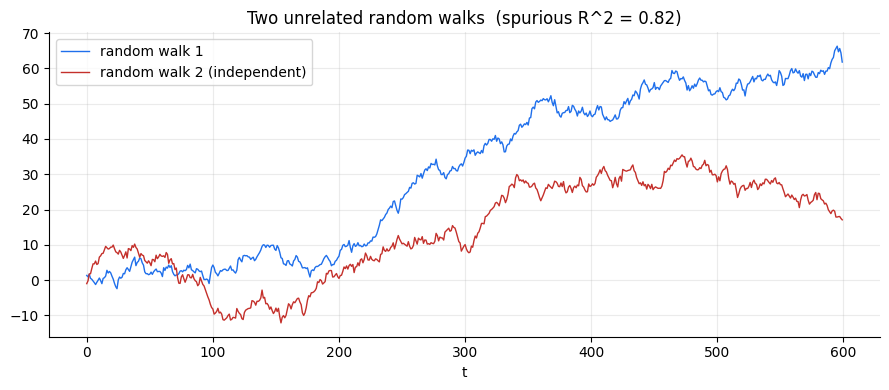

In [5]:
rng2 = np.random.default_rng(123)
n_trials, L = 200, 600
r2s, ts, coint = [], [], 0
best_r2, best_pair, best_t = -1.0, None, 0.0
for _ in range(n_trials):
    a = np.cumsum(rng2.normal(0, 1, L))
    b = np.cumsum(rng2.normal(0, 1, L))          # totally independent of a
    o = ols(b, a)
    r2s.append(o['r2']); ts.append(abs(o['t'][1]))
    if engle_granger(a, b).cointegrated:         # proper test at 5%
        coint += 1
    if o['r2'] > best_r2:                          # keep the most spurious-looking pair
        best_r2, best_pair, best_t = o['r2'], (a, b), float(o['t'][1])
print(f'Across {n_trials} INDEPENDENT random-walk pairs:')
print(f'  mean R^2 = {np.mean(r2s):.2f}   median |slope t| = {np.median(ts):.0f}  '
      '(OLS makes them look HIGHLY significant)')
print(f'  Engle-Granger flags cointegration in only {coint / n_trials:.0%}  '
      '-> it correctly rejects the spurious link')

# The single most spurious-looking pair from the sweep.
rw1, rw2 = best_pair
eg = engle_granger(rw1, rw2)
print(f'\nmost spurious example: R^2={best_r2:.2f}, slope t={best_t:.1f}  ->  '
      f'EG cointegrated={eg.cointegrated} (p={eg.p_value:.2f})  => correctly flagged spurious')
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rw1, color='#1f6feb', lw=1.0, label='random walk 1')
ax.plot(rw2, color='#c4302b', lw=1.0, label='random walk 2 (independent)')
ax.set_title(f'Two unrelated random walks  (spurious R^2 = {best_r2:.2f})')
ax.set_xlabel('t'); ax.legend()
plt.tight_layout(); plt.show()


## 5. Residual diagnostics

OLS inference assumes residuals are independent and roughly normal. Two quick
checks (both in `qufin.timeseries`):

* **Ljung–Box** — are the residuals autocorrelated? (Significant autocorrelation
  means the standard errors are wrong and a time-series model is needed.)
* **Jarque–Bera** — are they normal? (Financial residuals rarely are — fat tails.)


In [6]:
lb = ljung_box(capm['resid'], lags=10)
jb = jarque_bera(capm['resid'])
print('CAPM residual diagnostics:')
print(f'  Ljung-Box(10): Q={lb[0]:.1f}  p={lb[1]:.3f}  -> '
      f'{"autocorrelated" if lb[1] < 0.05 else "no leftover autocorrelation"}')
print(f'  Jarque-Bera : JB={jb[0]:.0f}  p={jb[1]:.2e}  -> '
      f'{"non-normal (fat tails)" if jb[1] < 0.05 else "consistent with normal"}')


CAPM residual diagnostics:
  Ljung-Box(10): Q=14.7  p=0.142  -> no leftover autocorrelation
  Jarque-Bera : JB=3471  p=0.00e+00  -> non-normal (fat tails)


## What next?

* **ARIMA (notebook 14)** models the autocorrelation OLS residuals can carry, and
  formalises the stationarity tests used here.
* **Cointegration & pairs (notebook 20)** is the *right* way to regress
  non-stationary price series on each other — when the residual *is* stationary,
  the relationship is real and tradeable.
* **Portfolio optimization (notebook 24)** uses regression betas as factor
  exposures; **Kalman filtering** (inside the pairs tutorial) makes the hedge
  ratio time-varying.
